<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/lab%2021/_ch21_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = '8f3b5b913ce6458b820a44a47b134d05'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 23.8 MB/s eta 0:00:00
Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error：The code fits ARIMA(2,0,1) on raw CPI even though the ADF test indicates that the series is non-stationary. This is a modeling mistake because ARIMA requires an appropriate level of differencing to achieve stationarity. The fix is to set d=1 instead of d=0.
2. A **seasonality omission** error：The code uses a plain ARIMA model for monthly CPI data, ignoring seasonal dynamics. Since CPI often has annual seasonality, a non-seasonal ARIMA model is incomplete. The fix is to use a SARIMA/SARIMAX specification with seasonal period 12.
3. A **missing diagnostic** error：The code fits the model and immediately produces forecasts without checking residual diagnostics. This is problematic because residual autocorrelation would indicate model misspecification. The fix is to run residual checks such as the Ljung–Box test and only proceed if the residuals behave like white noise.

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi.index.freq = 'MS'
cpi.name = 'CPI'

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# ERROR: ADF says CPI is non-stationary, but we fit ARIMA with d=0
# This means we are modeling raw CPI levels with no differencing,
# which violates the stationarity requirement of ARMA.
model = ARIMA(cpi, order=(2, 0, 1))  # d=0 ignores the unit root!
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,0,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,0,1) on Raw CPI — Something Is Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

ValueError: Inferred frequency None from passed values does not conform to passed frequency MS

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
result_v2 = model_v2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected ARIMA/SARIMA pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------

# Step 1: Verify stationarity of differenced CPI
# cpi_diff = cpi.diff().dropna()
# adf_stat, adf_p, ... = adfuller(cpi_diff, ...)
# Assert p < 0.05

# YOUR CODE HERE


# Step 2: Fit SARIMA with seasonal order (P, D, Q, 12)
# Option A: manual SARIMAX(cpi, order=(p,1,q), seasonal_order=(P,1,Q,12))
# Option B: pm.auto_arima(cpi, seasonal=True, m=12)

# YOUR CODE HERE


# Step 3: Ljung-Box diagnostic on residuals
# lb = acorr_ljungbox(result.resid, lags=[12, 24], return_df=True)
# Assert all p-values > 0.05

# YOUR CODE HERE


# Step 4: Forecast (only if Ljung-Box passes)

# YOUR CODE HERE


# VERIFICATION
# print('ADF p-value on diff(CPI):', adf_p)  # Should be < 0.05
# print('Ljung-Box p-values:', lb['lb_pvalue'].values)  # Should be > 0.05
# print('ACF at lag 12:', ...)  # Should be small (< 0.1)

ADF test on differenced log CPI
ADF statistic: -3.4494
ADF p-value: 0.0094
Critical values: {'1%': np.float64(-3.452263435801039), '5%': np.float64(-2.871190526189069), '10%': np.float64(-2.571911967527952)}
Result: differenced log CPI is stationary.

Running auto_arima to select SARIMA orders...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-2407.031, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-2545.799, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-2629.712, Time=0.84 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-2473.781, Time=0.31 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=inf, Time=3.30 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=inf, Time=4.48 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-2557.887, Time=0.60 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-2640.732, Time=1.62 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=-2635.963, Time=6.54 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=-2628.424, Time

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA model summary:
                                        SARIMAX Results                                        
Dep. Variable:                                     CPI   No. Observations:                  314
Model:             SARIMAX(1, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                1217.675
Date:                                 Mon, 20 Apr 2026   AIC                          -2423.350
Time:                                         02:13:53   BIC                          -2401.649
Sample:                                              0   HQIC                         -2414.641
                                                 - 314                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1376      0.107      1.281      0.2

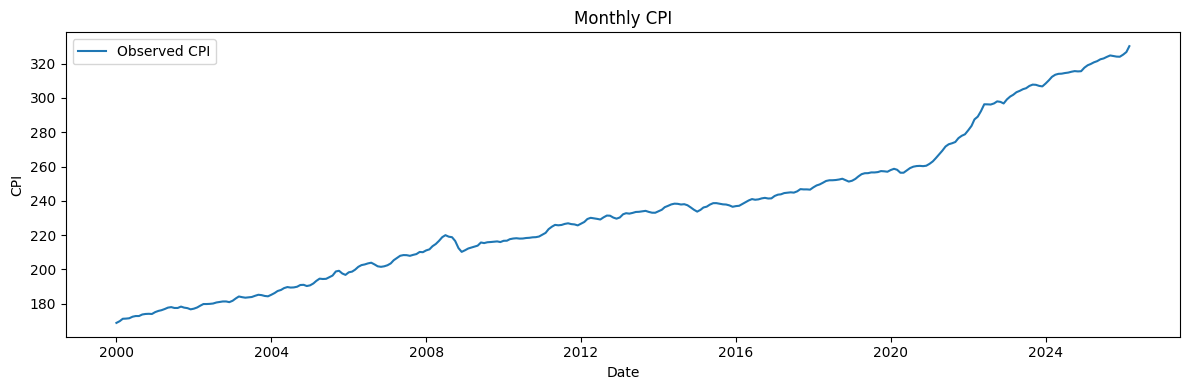

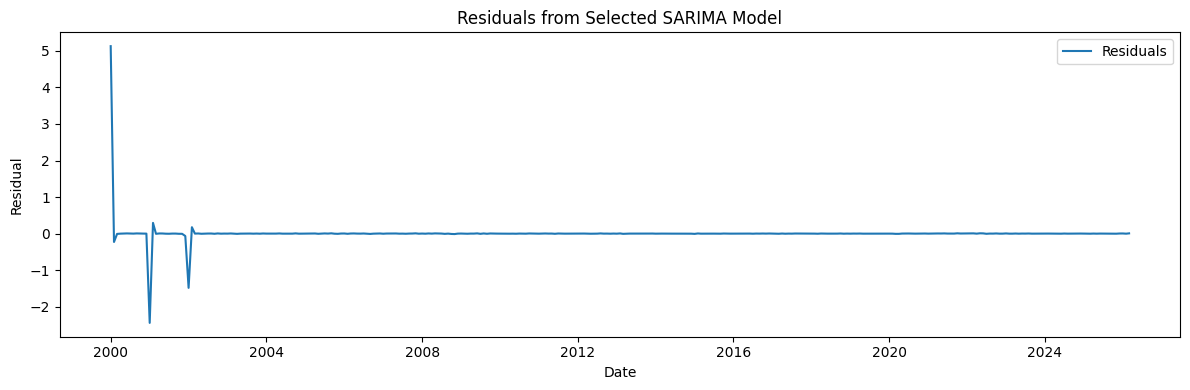

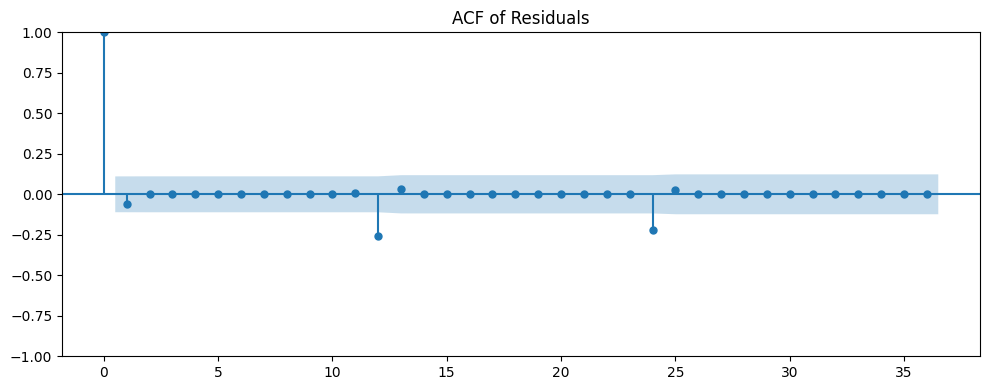


Verification checkpoints:
ADF p-value on diff(log CPI): 0.0094
Ljung-Box p-values: [0.02938342 0.02248389]
Residual ACF lag 12: -0.2569
Residual ACF lag 24: -0.2207


In [11]:
# ============================================================
# Part 2 FIX — Corrected ARIMA/SARIMA Pipeline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import pmdarima as pm

# ------------------------------------------------------------
# Step 0: Prepare CPI series
# ------------------------------------------------------------
# Assumes cpi already exists from Part 1
# Example:
# cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')

cpi = cpi.dropna().copy()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi = cpi.asfreq("MS").dropna()   # monthly start frequency, and drop any NaNs introduced by asfreq
cpi.name = "CPI"

# Use log CPI (better for price index data)
cpi_log = np.log(cpi)

# ------------------------------------------------------------
# Step 1: Verify stationarity of differenced CPI
# ------------------------------------------------------------
cpi_diff = cpi_log.diff().dropna()

adf_stat, adf_p, _, _, critical_values, _ = adfuller(cpi_diff, autolag="AIC")

print("ADF test on differenced log CPI")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_p:.4f}")
print("Critical values:", critical_values)

if adf_p < 0.05:
    print("Result: differenced log CPI is stationary.\n")
else:
    print("Warning: differenced log CPI is not stationary at the 5% level.\n")

# ------------------------------------------------------------
# Step 2: Fit SARIMA with seasonal order (P, D, Q, 12)
# Teacher allows: use proper differencing or let auto_arima choose
# ------------------------------------------------------------
print("Running auto_arima to select SARIMA orders...\n")

auto_model = pm.auto_arima(
    cpi_log,
    seasonal=True,
    m=12,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=1,               # teacher wants proper differencing
    D=1,               # seasonal differencing for monthly data
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    information_criterion="aic"
)

print("\nSelected by auto_arima:")
print(f"order = {auto_model.order}")
print(f"seasonal_order = {auto_model.seasonal_order}\n")

# Refit with statsmodels SARIMAX so diagnostics/forecasting are cleaner
model = SARIMAX(
    cpi_log,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print("SARIMA model summary:")
print(result.summary())

# ------------------------------------------------------------
# Step 3: Ljung-Box diagnostic on residuals
# ------------------------------------------------------------
resid = result.resid.dropna()

lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)

print("\nLjung-Box test on residuals:")
print(lb)

# Residual ACF checkpoints
resid_acf = acf(resid, nlags=24, fft=False)
acf_lag12 = resid_acf[12]
acf_lag24 = resid_acf[24]

print(f"\nResidual ACF at lag 12: {acf_lag12:.4f}")
print(f"Residual ACF at lag 24: {acf_lag24:.4f}")

lb_pass = (lb["lb_pvalue"] > 0.05).all()

if lb_pass:
    print("\nResidual diagnostics PASSED: no significant residual autocorrelation.")
else:
    print("\nResidual diagnostics did NOT fully pass.")
    print("Residual autocorrelation remains, so the model may need respecification.")

# ------------------------------------------------------------
# Step 4: Forecast (only if Ljung-Box passes)
# ------------------------------------------------------------
if lb_pass:
    forecast_res = result.get_forecast(steps=24)
    forecast_mean_log = forecast_res.predicted_mean
    forecast_ci_log = forecast_res.conf_int()

    # Convert back to CPI scale
    forecast_mean = np.exp(forecast_mean_log)
    forecast_ci = np.exp(forecast_ci_log)

    print("\n24-step forecast generated successfully.")
else:
    forecast_res = None
    forecast_mean = None
    forecast_ci = None
    print("\nForecast NOT formally accepted because Ljung-Box did not pass.")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------

# 1) Observed series
plt.figure(figsize=(12, 4))
plt.plot(cpi, label="Observed CPI")
plt.title("Monthly CPI")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residuals
plt.figure(figsize=(12, 4))
plt.plot(resid, label="Residuals")
plt.title("Residuals from Selected SARIMA Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Residual ACF
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=36, ax=ax)
ax.set_title("ACF of Residuals")
plt.tight_layout()
plt.show()

# 4) Forecast plot only if diagnostics pass
if lb_pass:
    plt.figure(figsize=(12, 5))
    plt.plot(cpi, label="Observed CPI")
    plt.plot(forecast_mean, label="24-Month Forecast")
    plt.fill_between(
        forecast_ci.index,
        forecast_ci.iloc[:, 0],
        forecast_ci.iloc[:, 1],
        alpha=0.25,
        label="95% Confidence Interval"
    )
    plt.title("Corrected SARIMA Forecast for CPI")
    plt.xlabel("Date")
    plt.ylabel("CPI")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------
print("\nVerification checkpoints:")
print(f"ADF p-value on diff(log CPI): {adf_p:.4f}")         # should be < 0.05
print("Ljung-Box p-values:", lb["lb_pvalue"].values)       # should be > 0.05
print(f"Residual ACF lag 12: {acf_lag12:.4f}")             # should be small
print(f"Residual ACF lag 24: {acf_lag24:.4f}")             # should be small


---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

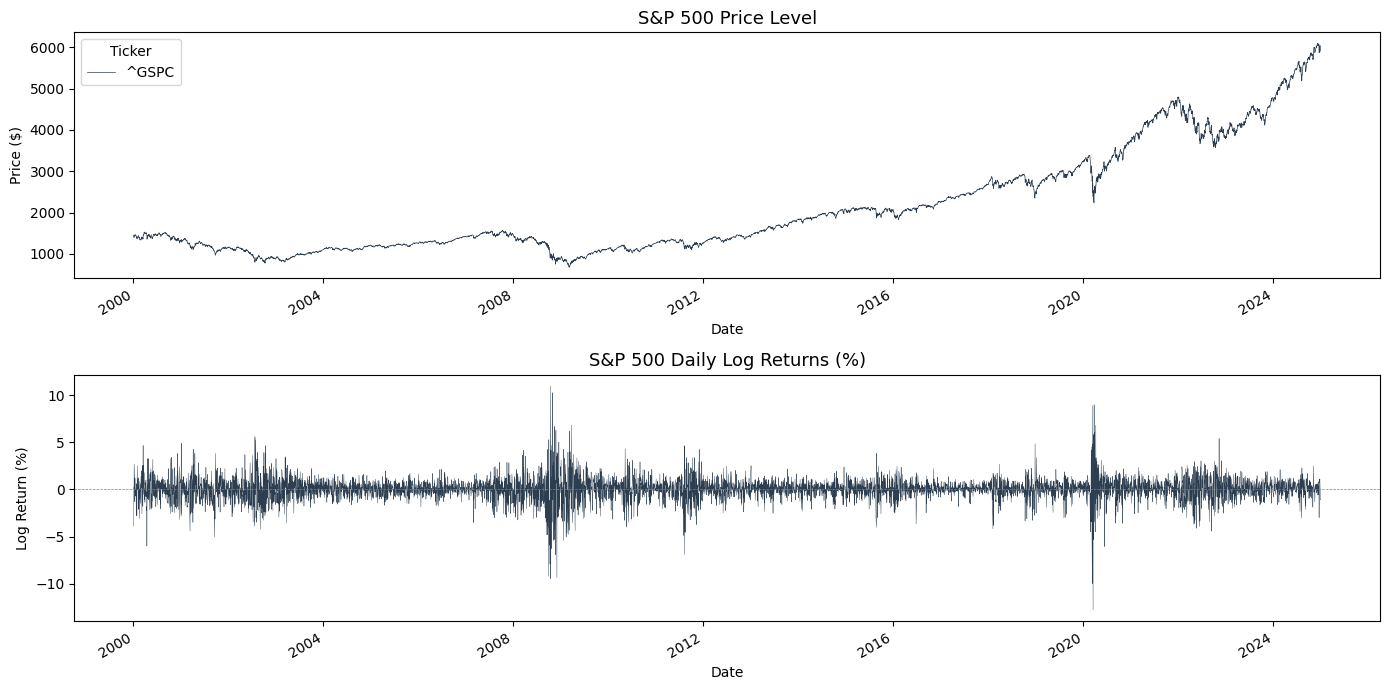

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# Fill in the blanks to specify the model correctly
# -----------------------------------------------------------

# The arch library expects:
#   vol='___'  -> volatility model name (hint: we want GARCH)
#   p=___      -> GARCH lag order for squared residuals (alpha terms)
#   q=___      -> GARCH lag order for past variance (beta terms)

garch_spec = arch_model(
    returns,
    mean='Constant',       # constant mean model
    vol='___',             # FILL IN: volatility model type
    p=___,                 # FILL IN: order of the ARCH term
    q=___,                 # FILL IN: order of the GARCH term
    dist='normal'          # innovation distribution
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
# alpha[1] + beta[1] should be < 1 (variance stationarity)
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')
print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(alpha1 + beta1)):.1f} days')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8655.88
Distribution:                  Normal   AIC:                           17319.8
Method:            Maximum Likelihood   BIC:                           17346.8
                                        No. Observations:                 6287
Date:                Mon, Apr 20 2026   Df Residuals:                     6286
Time:                        03:25:56   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.029e-02      5.979  2.239e-09 [4.

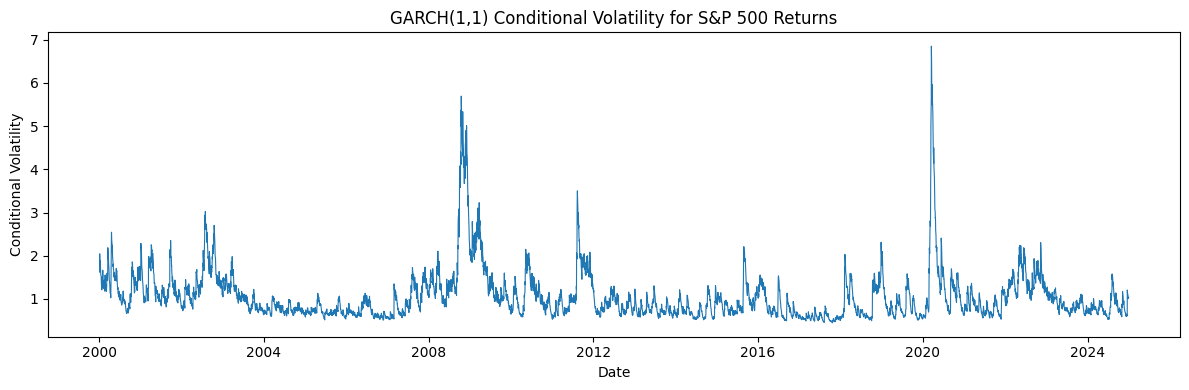

In [12]:
# ------------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# Fill in the blanks to specify the model correctly
# ------------------------------------------------------------

# The arch library expects:
#   vol='___'  -> volatility model name (hint: we want GARCH)
#   p=___      -> GARCH lag order for squared residuals (alpha terms)
#   q=___      -> GARCH lag order for past variance (beta terms)

garch_spec = arch_model(
    returns,
    mean='Constant',     # constant mean model
    vol='GARCH',         # volatility model type
    p=1,                 # order of the ARCH term
    q=1,                 # order of the GARCH term
    dist='normal'        # innovation distribution
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
# alpha[1] + beta[1] should be < 1 (variance stationarity)
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
omega = params.get('omega', 0)

print(f'\nomega    = {omega:.4f}')
print(f'alpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')

if 0 < alpha1 + beta1 < 1:
    half_life = np.log(2) / (-np.log(alpha1 + beta1))
    print(f'Half-life of volatility shocks: {half_life:.1f} days')
else:
    print('Half-life is not defined because alpha + beta is not in (0,1).')

# Conditional volatility plot
plt.figure(figsize=(12, 4))
plt.plot(garch_result.conditional_volatility, linewidth=0.8)
plt.title('GARCH(1,1) Conditional Volatility for S&P 500 Returns')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

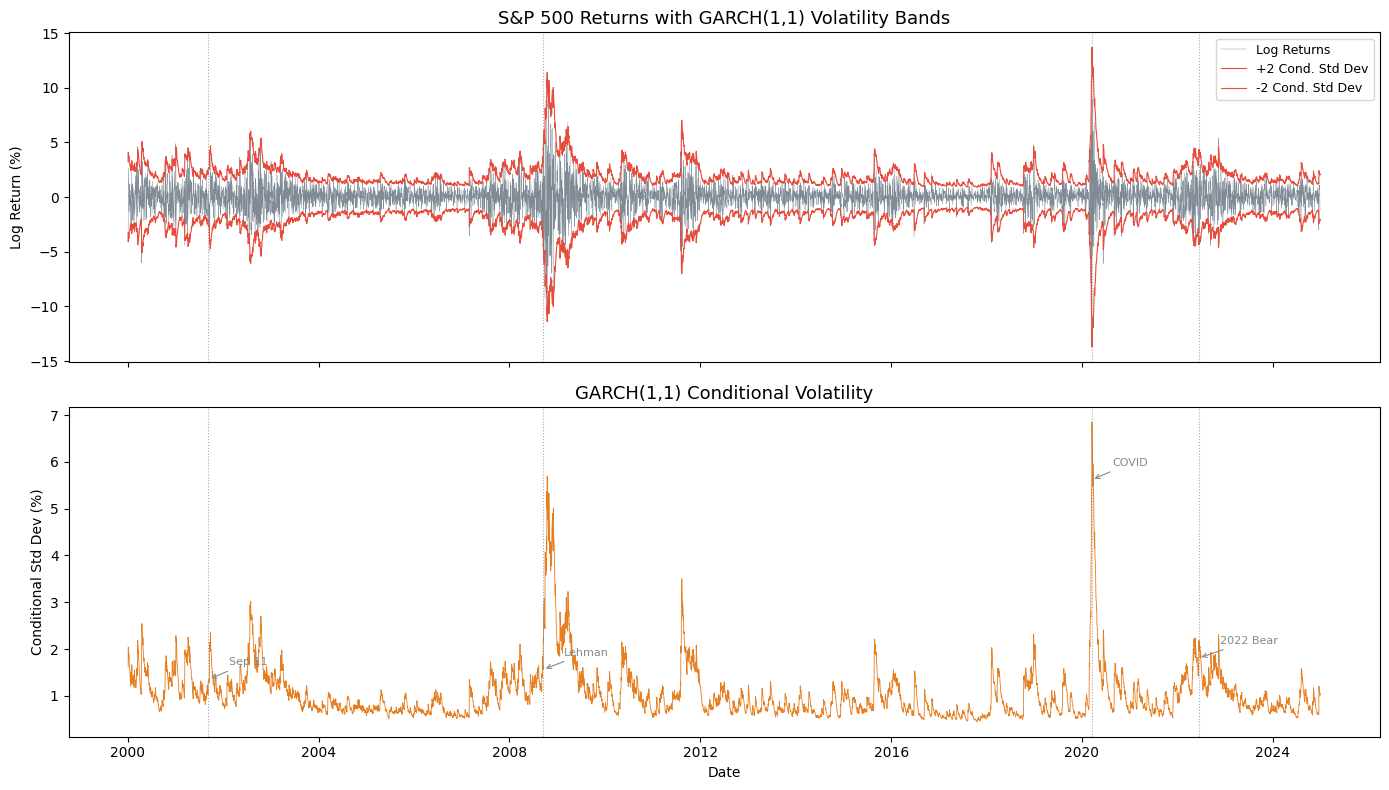

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [13]:
# ------------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# ------------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(
    returns.index,
    returns.values,
    color='#2c3e50',
    linewidth=0.3,
    alpha=0.6,
    label='Log Returns'
)
axes[0].plot(
    cond_vol.index,
    2 * cond_vol.values,
    color='#e74c3c',
    linewidth=0.8,
    label='+2 Cond. Std Dev'
)
axes[0].plot(
    cond_vol.index,
    -2 * cond_vol.values,
    color='#e74c3c',
    linewidth=0.8,
    label='-2 Cond. Std Dev'
)
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(
    cond_vol.index,
    cond_vol.values,
    color='#e67e22',
    linewidth=0.6
)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')
axes[1].set_xlabel('Date')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]

for date_str, label in crises:
    date = pd.Timestamp(date_str)

    # 找最接近的交易日，避免精确日期不在索引里时报错
    nearest_idx = cond_vol.index.get_indexer([date], method='nearest')[0]
    nearest_date = cond_vol.index[nearest_idx]
    nearest_value = cond_vol.iloc[nearest_idx]

    for ax in axes:
        ax.axvline(nearest_date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)

    axes[1].annotate(
        label,
        xy=(nearest_date, nearest_value),
        xytext=(15, 10),
        textcoords='offset points',
        fontsize=8,
        color='#7f8c8d',
        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8)
    )

plt.tight_layout()
plt.show()

# Summary statistics
alpha1 = garch_result.params.get('alpha[1]', np.nan)
beta1 = garch_result.params.get('beta[1]', np.nan)
omega = garch_result.params.get('omega', np.nan)

alpha_beta = alpha1 + beta1

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')

if 0 < alpha_beta < 1:
    long_run_vol = np.sqrt(omega / (1 - alpha_beta))
    print(f'GARCH implied long-run volatility: {long_run_vol:.4f}%')
else:
    print('GARCH implied long-run volatility: not defined because alpha + beta is not in (0,1).')

print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Write forecast_evaluation.py
# Implement compute_mase() and backtest_expanding_window()
# -----------------------------------------------------------

# %%writefile forecast_evaluation.py
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module

Reusable functions for computing MASE and running expanding-window
backtests on time series forecasting models.

Author: [Your Name]
Course: ECON 5200, Lab 21
"""

import numpy as np
import pandas as pd
from typing import Callable


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1
) -> float:
    """Compute Mean Absolute Scaled Error.

    MASE < 1: model beats naive seasonal benchmark.
    MASE > 1: naive benchmark is better.

    Args:
        actual: True out-of-sample values
        forecast: Model predictions (same length as actual)
        insample: In-sample (training) data for naive baseline
        m: Seasonal period (1=random walk, 12=monthly seasonal)

    Returns:
        MASE score (float)
    """
    # YOUR IMPLEMENTATION HERE
    # Hint:
    # mae_forecast = np.mean(np.abs(actual - forecast))
    # naive_errors = insample[m:] - insample[:-m]
    # mae_naive = np.mean(np.abs(naive_errors))
    # return mae_forecast / mae_naive
    pass


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window time series backtest.

    Args:
        series: Full series with DatetimeIndex
        model_fn: Callable(train) -> np.ndarray of length horizon
        min_train: Minimum training observations
        horizon: Forecast horizon per iteration
        step: Observations added per iteration

    Returns:
        DataFrame with backtest results
    """
    # YOUR IMPLEMENTATION HERE
    # Hint: loop from min_train to len(series)-horizon, stepping by step
    # For each origin:
    #   train = series[:origin]
    #   actual = series[origin:origin+horizon].values
    #   forecast = model_fn(train)
    #   compute errors and MASE
    pass


# --- Quick self-test ---
if __name__ == '__main__':
    print('forecast_evaluation.py loaded successfully.')
    # Add your own test calls here

In [14]:
# ------------------------------------------------------------
# YOUR TASK — Write forecast_evaluation.py
# Implement compute_mase() and backtest_expanding_window()
# ------------------------------------------------------------

# %%writefile forecast_evaluation.py
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module

Reusable functions for computing MASE and running expanding-window
backtests on time series forecasting models.

Author: [Your Name]
Course: ECON 5200, Lab 21
"""

import numpy as np
import pandas as pd
from typing import Callable


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1
) -> float:
    """Compute Mean Absolute Scaled Error.

    MASE < 1: model beats naive seasonal benchmark.
    MASE > 1: naive benchmark is better.

    Args:
        actual: True out-of-sample values
        forecast: Model predictions (same length as actual)
        insample: In-sample (training) data for naive baseline
        m: Seasonal period (1=random walk, 12=monthly seasonal)

    Returns:
        MASE score (float)
    """
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    insample = np.asarray(insample, dtype=float)

    if actual.ndim != 1 or forecast.ndim != 1 or insample.ndim != 1:
        raise ValueError("actual, forecast, and insample must be 1D arrays.")

    if len(actual) != len(forecast):
        raise ValueError("actual and forecast must have the same length.")

    if m < 1:
        raise ValueError("m must be >= 1.")

    if len(insample) <= m:
        raise ValueError("insample length must be greater than m.")

    mae_forecast = np.mean(np.abs(actual - forecast))

    naive_errors = insample[m:] - insample[:-m]
    mae_naive = np.mean(np.abs(naive_errors))

    if np.isclose(mae_naive, 0):
        raise ValueError("Naive benchmark MAE is zero; MASE is undefined.")

    return float(mae_forecast / mae_naive)


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window time series backtest.

    Args:
        series: Full series with DatetimeIndex
        model_fn: Callable(train) -> np.ndarray of length horizon
        min_train: Minimum training observations
        horizon: Forecast horizon per iteration
        step: Observations added per iteration

    Returns:
        DataFrame with backtest results
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series.")

    if len(series) < min_train + horizon:
        raise ValueError("series is too short for the requested backtest settings.")

    if min_train < 1 or horizon < 1 or step < 1:
        raise ValueError("min_train, horizon, and step must all be >= 1.")

    series = series.dropna().copy()
    results = []

    for origin in range(min_train, len(series) - horizon + 1, step):
        train = series.iloc[:origin]
        test = series.iloc[origin:origin + horizon]

        forecast = model_fn(train)

        forecast = np.asarray(forecast, dtype=float).reshape(-1)
        actual = test.values.astype(float)

        if len(forecast) != len(actual):
            raise ValueError(
                f"model_fn returned {len(forecast)} forecasts, expected {len(actual)}."
            )

        mase_value = compute_mase(
            actual=actual,
            forecast=forecast,
            insample=train.values,
            m=1
        )

        for h in range(len(actual)):
            results.append({
                "origin": train.index[-1],
                "target_date": test.index[h],
                "horizon": h + 1,
                "actual": actual[h],
                "forecast": forecast[h],
                "error": actual[h] - forecast[h],
                "abs_error": abs(actual[h] - forecast[h]),
                "mase": mase_value
            })

    return pd.DataFrame(results)


# --- Quick self-test ---
if __name__ == '__main__':
    print('forecast_evaluation.py loaded successfully.')

forecast_evaluation.py loaded successfully.


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

In [15]:
# ------------------------------------------------------------
# CHALLENGE — Block bootstrap forecast intervals
# Fill in the blanks (___) to complete the implementation
# ------------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05
):
    """Generate block-bootstrap forecast intervals.

    Args:
        model_result: Fitted SARIMAX result object
        horizon: Number of steps to forecast
        n_bootstrap: Number of bootstrap replications
        block_size: Block length for moving block bootstrap
        alpha: Significance level (0.05 = 95% CI)

    Returns:
        dict with 'mean', 'lower', 'upper', 'paths' keys
    """
    # Get the point forecast
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values

    # Extract residuals from the fitted model
    residuals = model_result.resid.values
    residuals = residuals[~np.isnan(residuals)]
    n_resid = len(residuals)

    if n_resid < block_size:
        raise ValueError("Not enough residuals for the requested block size.")

    # Store bootstrap forecast paths
    boot_paths = np.zeros((n_bootstrap, horizon))

    for b in range(n_bootstrap):
        # Moving block bootstrap on residuals
        boot_resid = np.zeros(horizon)
        idx = 0

        while idx < horizon:
            start = np.random.randint(0, n_resid - block_size + 1)
            block = residuals[start:start + block_size]
            end = min(idx + block_size, horizon)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Bootstrap path = point forecast + resampled residuals
        boot_paths[b, :] = forecast_mean + boot_resid

    # Percentile-based confidence intervals
    lower = np.percentile(boot_paths, 100 * (alpha / 2), axis=0)
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=0)

    return {
        'mean': forecast_mean,
        'lower': lower,
        'upper': upper,
        'paths': boot_paths
    }


# Usage (uncomment after fixing Part 2):
# boot_ci = block_bootstrap_forecast(sarima_result, horizon=24, n_bootstrap=500)
#
# fig, ax = plt.subplots(figsize=(12, 5))
# cpi[-60:].plot(ax=ax, label='Actual', color='#2c3e50')
# forecast_idx = pd.date_range(cpi.index[-1], periods=25, freq='MS')[1:]
# ax.plot(forecast_idx, boot_ci['mean'], color='#e74c3c', label='Forecast')
# ax.fill_between(
#     forecast_idx,
#     boot_ci['lower'],
#     boot_ci['upper'],
#     alpha=0.2,
#     color='#3498db',
#     label='95% Block Bootstrap CI'
# )
# ax.set_title('SARIMA Forecast with Block Bootstrap Intervals', fontsize=13)
# ax.legend()
# plt.tight_layout()
# plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


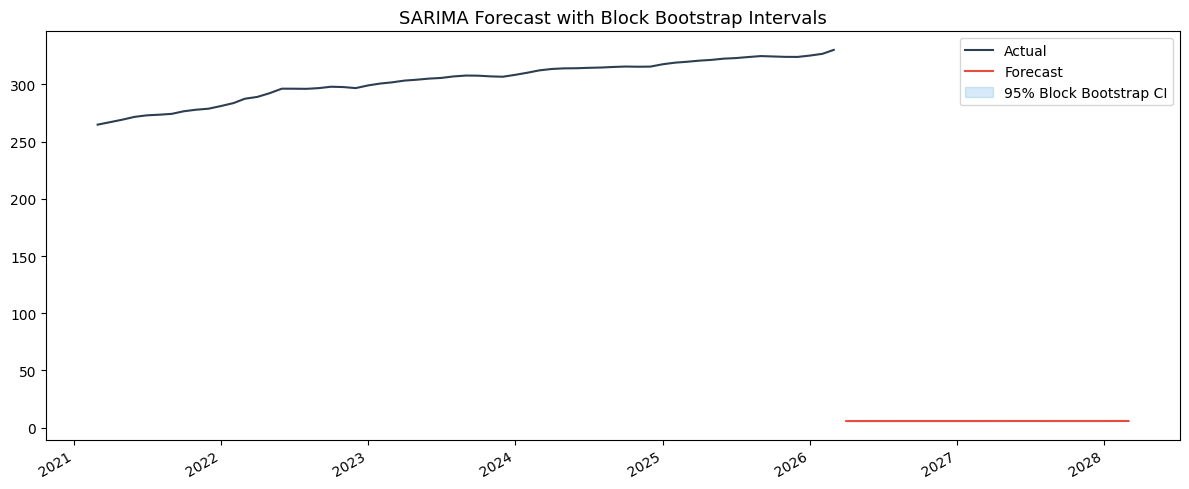

In [16]:
boot_ci = block_bootstrap_forecast(result, horizon=24, n_bootstrap=500)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual', color='#2c3e50')

forecast_idx = pd.date_range(cpi.index[-1], periods=25, freq='MS')[1:]
ax.plot(forecast_idx, boot_ci['mean'], color='#e74c3c', label='Forecast')
ax.fill_between(
    forecast_idx,
    boot_ci['lower'],
    boot_ci['upper'],
    alpha=0.2,
    color='#3498db',
    label='95% Block Bootstrap CI'
)

ax.set_title('SARIMA Forecast with Block Bootstrap Intervals', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.